In [2]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

#opciones para la visualizacion de las tablas
pd.set_option('display.max_columns', None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#gestion de warning
warnings.filterwarnings('ignore')

print("Configuración del entorno\n")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Configuración del entorno

Pandas: 2.2.2
Numpy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [3]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Ruta de acceso del dataset
project_folder_path = '/content/drive/MyDrive/Colab Notebooks'

#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v01_version_para_regresion.csv'
#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v02_regresion_ventas_brutas.csv'

dataset = '/content/drive/MyDrive/Colab Notebooks/data_v07_con_fechas_regresion_devoluciones.csv'

In [5]:
#cargamos el dataset y mostramos las primeras filas
try:
    dfc_devoluciones = pd.read_csv(dataset, encoding="ISO-8859-1")
    print(f"Archivo {dataset} cargado exitosamente.")
    display(dfc_devoluciones.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {dataset}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo /content/drive/MyDrive/Colab Notebooks/data_v07_con_fechas_regresion_devoluciones.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom,1,12,2010,9,2,1,-4.65
1,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom,1,12,2010,10,2,1,-19.80
2,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
3,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
4,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96


In [ ]:
#Vista general del dataset

#Dimensiones de dataset
print("Dimensiones del dataset:")
print(f"Filas: {dfc_devoluciones.shape[0]}")
print(f"Columnas: {dfc_devoluciones.shape[1]}")

#Nombres de las columnas.
print("\nNombres de las columnas:")
print(dfc_devoluciones.columns)

#Primeras y ultimas 5 filas del dataset
print("\nPrimeras 5 filas del dataset:")
display(dfc_devoluciones.head())
print("\nUltimas 5 filas del dataset:")
display(dfc_devoluciones.tail())

#tipos de datos y estructura
print("\nTipos de datos y estructura del dataset:")
display(dfc_devoluciones.info())

#resumen estadistico
print("\nResumen estadístico del dataset:")
display(dfc_devoluciones.describe())

#resumen descriptivo
print("\nResumen descriptivo del dataset:")
display(dfc_devoluciones.describe(include='object'))



Dimensiones del dataset:
Filas: 8108
Columnas: 15

Nombres de las columnas:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country',
       'InvoiceDay', 'InvoiceMonth', 'InvoiceYear', 'InvoiceHour', 'DayOfWeek', 'IsUk', 'TotalPrice'],
      dtype='object')

Primeras 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom,1,12,2010,9,2,1,-4.65
1,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom,1,12,2010,10,2,1,-19.80
2,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
3,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
4,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96



Ultimas 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
8103,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,"14,397.00",United Kingdom,9,12,2011,9,4,1,-23.40
8104,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,"14,397.00",United Kingdom,9,12,2011,9,4,1,-9.13
8105,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,"15,311.00",United Kingdom,9,12,2011,11,4,1,-54.75
8106,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,"17,315.00",United Kingdom,9,12,2011,11,4,1,-1.25
8107,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,2011-12-09 11:58:00,1.25,"17,315.00",United Kingdom,9,12,2011,11,4,1,-6.25



Tipos de datos y estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8108 entries, 0 to 8107
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   InvoiceNo     8108 non-null   object 
 1   StockCode     8108 non-null   object 
 2   Description   8108 non-null   object 
 3   Quantity      8108 non-null   int64  
 4   InvoiceDate   8108 non-null   object 
 5   UnitPrice     8108 non-null   float64
 6   CustomerID    7954 non-null   float64
 7   Country       8108 non-null   object 
 8   InvoiceDay    8108 non-null   int64  
 9   InvoiceMonth  8108 non-null   int64  
 10  InvoiceYear   8108 non-null   int64  
 11  InvoiceHour   8108 non-null   int64  
 12  DayOfWeek     8108 non-null   int64  
 13  IsUk          8108 non-null   int64  
 14  TotalPrice    8108 non-null   float64
dtypes: float64(3), int64(7), object(5)
memory usage: 950.3+ KB


None


Resumen estadístico del dataset:


,Quantity,UnitPrice,CustomerID,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
count,"8,108.00","8,108.00","7,954.00","8,108.00","8,108.00","8,108.00","8,108.00","8,108.00","8,108.00","8,108.00"
mean,-11.88,4.44,"15,005.88",14.88,7.28,"2,010.92",13.20,2.24,0.85,-24.11
std,123.50,8.89,"1,708.58",8.69,3.55,0.27,2.76,1.55,0.36,146.75
min,"-9,360.00",0.03,"12,352.00",1.00,1.00,"2,010.00",6.00,0.00,0.00,"-6,539.40"
25%,-6.00,1.45,"13,534.00",7.00,4.00,"2,011.00",11.00,1.00,1.00,-15.81
50%,-2.00,2.89,"14,895.00",14.00,8.00,"2,011.00",13.00,2.00,1.00,-7.95
75%,-1.00,4.95,"16,422.00",22.00,10.00,"2,011.00",15.00,3.00,1.00,-3.25
max,-1.00,295.00,"18,282.00",31.00,12.00,"2,011.00",20.00,6.00,1.00,-0.12



Resumen descriptivo del dataset:


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,8108,8108,8108,8108,8108
unique,3299,1863,1888,3244,28
top,C570867,22423,REGENCY CAKESTAND 3 TIER,2011-10-12 16:17:00,United Kingdom
freq,101,172,172,101,6891


In [ ]:
# Getting the number of rows in the dataframe
dfc_devoluciones.shape[0]

8108

# Preprocesado y transformación de datos




In [6]:

import pandas as pd
import numpy as np

# Rangos exactos de tu proyecto
start_train = '2010-12-01'
end_train   = '2011-11-08'
start_val   = '2011-10-09'
end_val     = '2011-11-08'
start_test  = '2011-11-09'
end_test    = '2011-12-09'

def preprocess_returns_for_rf(df, target_col='TotalPrice'):
    # Convertir a valor absoluto para predecir "Volumen de Devolución"
    df[target_col] = df[target_col].abs()

    # Asegurar formato fecha y agrupar por día
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.normalize()
    df_daily = df.groupby('InvoiceDate')[target_col].sum().reset_index()
    df_daily.columns = ['date', 'daily_returns']

    # Rellenar los días sin devoluciones con ceros, para que al hacer lag_1 tome como referencia el día de antes (ya que si no se han hecho devoluciones en un día, tomaría como día anterior el último día en el que se realizó alguna devolución)
    df_daily.set_index('date', inplace=True)

    idx = pd.date_range(start=df_daily.index.min(), end=df_daily.index.max())
    df_daily = df_daily.reindex(idx, fill_value=0)
    df_daily = df_daily.reset_index().rename(columns={'index': 'date'})

   # FEATURE ENGINEERING (Ingeniería de Características)
    df_daily['month'] = df_daily['date'].dt.month
    df_daily['day_of_month'] = df_daily['date'].dt.day
    df_daily['day_of_week'] = df_daily['date'].dt.dayofweek
    df_daily['is_weekend'] = (df_daily['day_of_week'] >= 5).astype(int)

    # Variables de "Memoria" (Lags de devoluciones)
    df_daily['returns_lag_1'] = df_daily['daily_returns'].shift(1)
    df_daily['returns_lag_7'] = df_daily['daily_returns'].shift(7)

    # Medias Móviles
    df_daily['rolling_mean_7_returns'] = df_daily['daily_returns'].shift(1).rolling(window=7).mean()
    df_daily['rolling_mean_30_returns'] = df_daily['daily_returns'].shift(1).rolling(window=30).mean()

    # Tendencia
    df_daily['trend_1_vs_7_returns'] = df_daily['returns_lag_1'] - df_daily['returns_lag_7']

    # División de conjuntos (Train, Val, Test)
    df_train = df_daily[(df_daily['date'] >= start_train) & (df_daily['date'] <= end_train)].copy()
    df_val   = df_daily[(df_daily['date'] >= start_val)   & (df_daily['date'] <= end_val)].copy()
    df_test  = df_daily[(df_daily['date'] >= start_test)  & (df_daily['date'] <= end_test)].copy()

    print(f" ==== Reporte de Datos de DEVOLUCIONES: ====== ")
    print(f"   - Entrenamiento: {len(df_train)} días")
    print(f"   - Test Final:    {len(df_test)} días")
    print(f"   - Días con 0 devoluciones detectados y rellenados: {(df_daily['daily_returns'] == 0).sum()}")

    return df_train, df_val, df_test

# Ejecutamos asumiendo que tu dataset de devoluciones está en dfc_devoluciones
df_train, df_val, df_test = preprocess_returns_for_rf(dfc_devoluciones, 'TotalPrice')



 ==== Reporte de Datos de DEVOLUCIONES: ====== 
   - Entrenamiento: 343 días
   - Test Final:    31 días
   - Días con 0 devoluciones detectados y rellenados: 72


 Modelos VARIOS



 Procesando: Regresión Multilineal...
________________________________________________________________________________
 -> Entrenando modelo directo (sin hiperparámetros)...
 -> Resultados del Test | RMSE: £491.36 | MAE: £374.39 | R2: 0.2881
 -> ✅ Archivo guardado con éxito en: /content/drive/MyDrive/TFM_Prediccion_Devolu_Regresion_Multilineal.csv


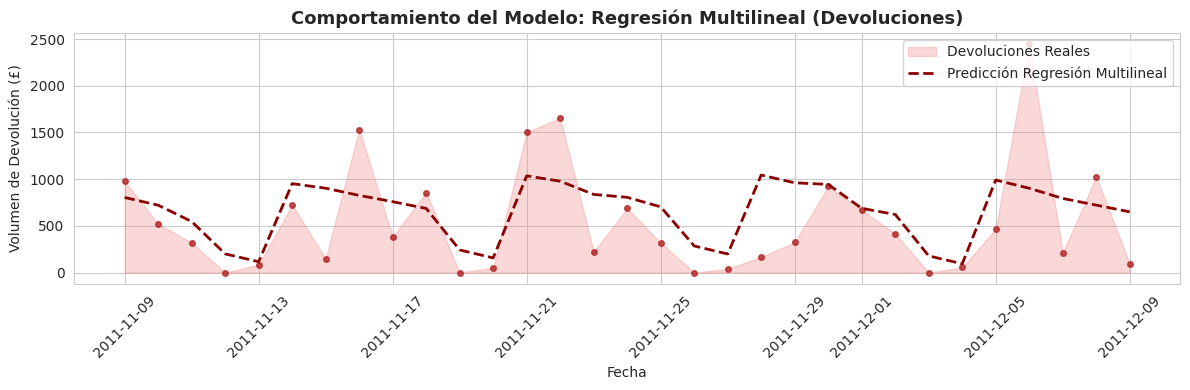

 Procesando: Regresión Polinómica (Grado 2)...
________________________________________________________________________________
 -> Entrenando modelo directo (sin hiperparámetros)...
 -> Resultados del Test | RMSE: £581.05 | MAE: £470.42 | R2: 0.0045
 -> ✅ Archivo guardado con éxito en: /content/drive/MyDrive/TFM_Prediccion_Devolu_Regresion_Polinomica_(Grado_2).csv


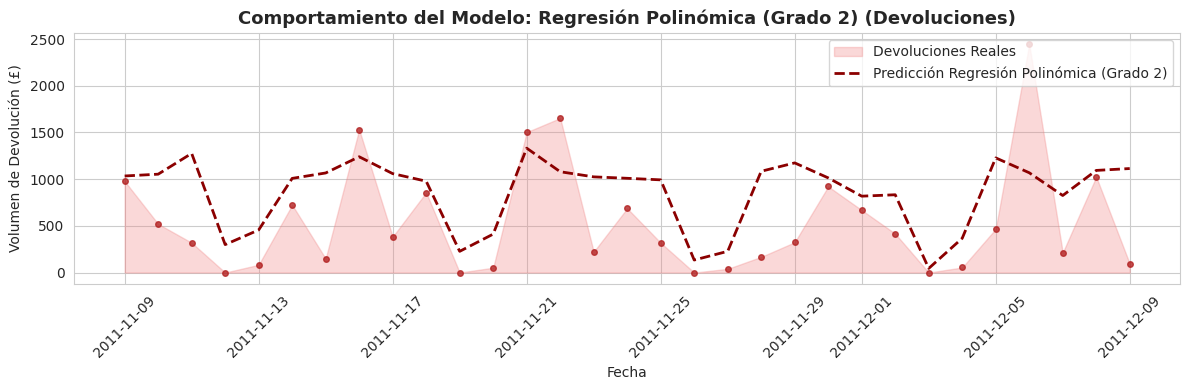

 Procesando: Árbol de Decisión...
________________________________________________________________________________
 -> Optimizando hiperparámetros con RandomizedSearchCV...
 -> Mejores parámetros: {'min_samples_split': 20, 'min_samples_leaf': 12, 'max_depth': 3}
 -> Resultados del Test | RMSE: £600.76 | MAE: £472.92 | R2: -0.0642
 -> ✅ Archivo guardado con éxito en: /content/drive/MyDrive/TFM_Prediccion_Devolu_Arbol_de_Decision.csv


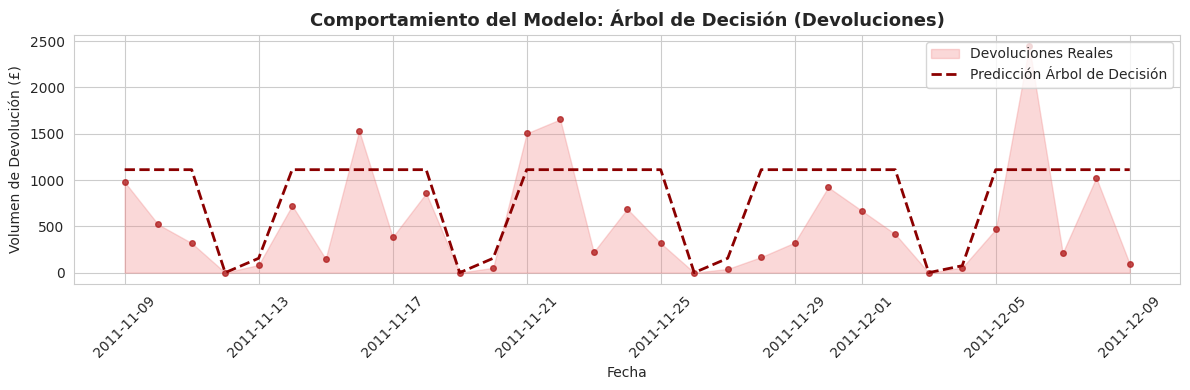

 Procesando: XGBoost...
________________________________________________________________________________
 -> Optimizando hiperparámetros con RandomizedSearchCV...
 -> Mejores parámetros: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}
 -> Resultados del Test | RMSE: £611.95 | MAE: £480.17 | R2: -0.1042
 -> ✅ Archivo guardado con éxito en: /content/drive/MyDrive/TFM_Prediccion_Devolu_XGBoost.csv


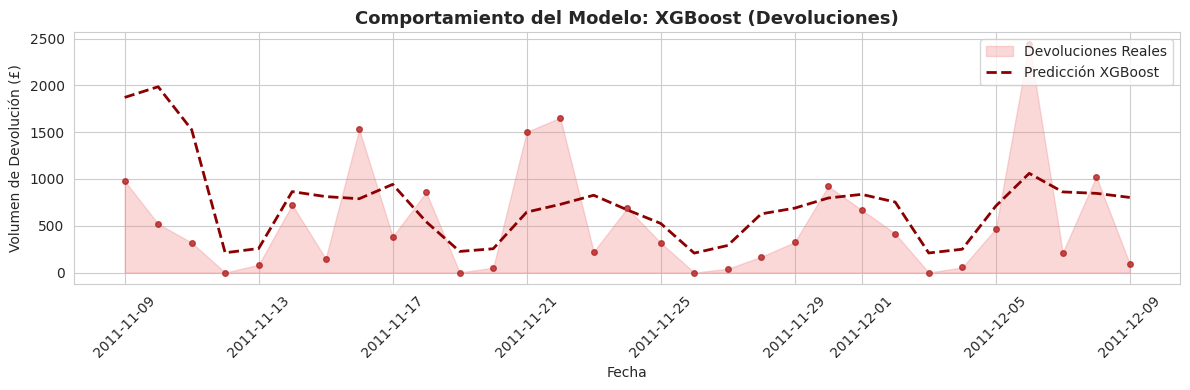


 TABLA DE RESULTADOS DEFINITIVOS DEVOLUCIONES (ORDENADA POR MENOR RMSE) 


,Modelo,MAE (£),RMSE (£),R2
0,Regresión Multilineal,374.39,491.36,0.29
1,Regresión Polinómica (Grado 2),470.42,581.05,0.00
2,Árbol de Decisión,472.92,600.76,-0.06
3,XGBoost,480.17,611.95,-0.10


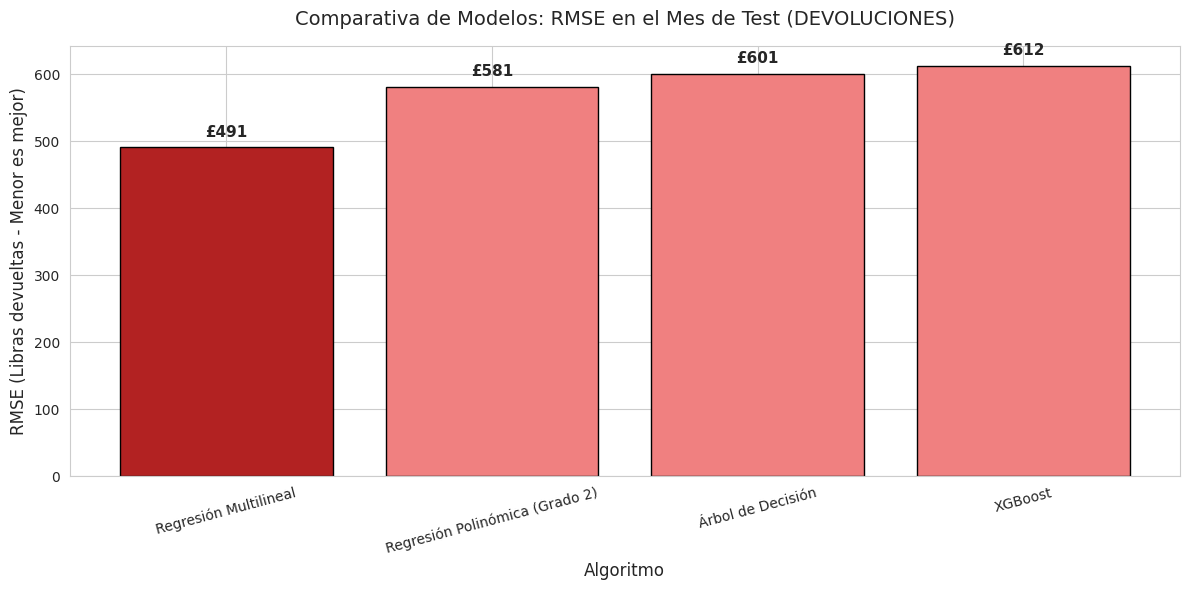

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Definimos las columnas predictoras (X) y el objetivo (y)
features = ['month', 'day_of_month', 'day_of_week', 'is_weekend', 'returns_lag_1', 'returns_lag_7' ,'rolling_mean_7_returns','rolling_mean_30_returns', 'trend_1_vs_7_returns']
target = 'daily_returns'

# 1. Asignamos las variables
X_train = df_train[features].copy()
y_train = df_train[target].copy()

X_test = df_test[features].copy()
y_test = df_test[target].copy()

# 2. ESCUDO ANTI-NaNs (Forzamos a que cualquier nulo rebelde sea un 0)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)
y_train = y_train.fillna(0)
y_test = y_test.fillna(0)


# CONFIGURACIÓN DE MODELOS Y VALIDACIÓN CRUZADA
tscv = TimeSeriesSplit(n_splits=3)

modelos = {
    "Regresión Multilineal": LinearRegression(),
    "Regresión Polinómica (Grado 2)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    "Árbol de Decisión": {
        'max_depth': [3, 5, 7],
        'min_samples_split': [10, 15, 20],
        'min_samples_leaf': [4, 8, 12]
    },
    "XGBoost": {
        'n_estimators': [100, 200, 300],
        'max_depth': [2, 3, 5],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.6, 0.8],
        'colsample_bytree': [0.6, 0.8],
        'gamma': [0.5, 1.0, 5.0]
    }
}

resultados = []
predicciones_test = {}


for nombre, modelo in modelos.items():

    print(f" Procesando: {nombre}...")
    print("_"*80)

    # OPTIMIZACIÓN Y ENTRENAMIENTO
    if nombre in param_grids:
        print(" -> Optimizando hiperparámetros con RandomizedSearchCV...")


        iteraciones = 40 if nombre == "XGBoost" else 10

        random_search = RandomizedSearchCV(
            estimator=modelo,
            param_distributions=param_grids[nombre],
            n_iter=iteraciones,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            random_state=42,
            n_jobs=-1
        )

        random_search.fit(X_train, y_train)
        mejor_modelo = random_search.best_estimator_
        print(f" -> Mejores parámetros: {random_search.best_params_}")

    else:
        # Si es regresión simple/polinómica, entrenamos directo
        print(" -> Entrenando modelo directo (sin hiperparámetros)...")
        mejor_modelo = modelo.fit(X_train, y_train)

    # PREDICCIÓN SOBRE EL MES DE TEST
    y_pred = mejor_modelo.predict(X_test)
    predicciones_test[nombre] = y_pred

    # CÁLCULO DE MÉTRICAS
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f" -> Resultados del Test | RMSE: £{rmse:,.2f} | MAE: £{mae:,.2f} | R2: {r2:.4f}")

    # Guardamos los resultados
    resultados.append({
        "Modelo": nombre,
        "MAE (£)": mae,
        "RMSE (£)": rmse,
        "R2": r2
    })

    df_devolu_eval = df_test.copy()
    df_devolu_eval['actual_returns'] = y_test
    df_devolu_eval['predicted_returns'] = y_pred

    # Aplicamos la Regla de Negocio (Excluir anomalía para coherencia con ventas)
    fecha_anomala = '2011-11-14'
    df_devolu_corregido = df_devolu_eval[df_devolu_eval['date'].astype(str) != fecha_anomala].copy()

    # Formateamos el nombre del modelo para que sea un nombre de archivo válido
    # (quitamos espacios y tildes)
    nombre_archivo = nombre.replace(" ", "_").replace("ó", "o").replace("í", "i").replace("Á", "A")
    ruta_drive = f'/content/drive/MyDrive/TFM_Prediccion_Devolu_{nombre_archivo}.csv'

    # Guardar el DataFrame
    df_devolu_corregido.to_csv(ruta_drive, index=False)
    print(f" -> ✅ Archivo guardado con éxito en: {ruta_drive}")

    plt.figure(figsize=(12, 4))

    # Sombreado de las devoluciones reales (Ground Truth)
    plt.fill_between(df_test['date'], y_test, color="lightcoral", alpha=0.3, label='Devoluciones Reales')
    plt.plot(df_test['date'], y_test, color="firebrick", marker='o', markersize=4, linestyle='', alpha=0.8)

    # Línea de la predicción del modelo
    plt.plot(df_test['date'], y_pred, color="darkred", lw=2, linestyle='--', label=f'Predicción {nombre}')

    # Estética del gráfico
    plt.title(f"Comportamiento del Modelo: {nombre} (Devoluciones)", fontsize=13, fontweight='bold')
    plt.xlabel("Fecha", fontsize=10)
    plt.ylabel("Volumen de Devolución (£)", fontsize=10)
    plt.xticks(rotation=45)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Convertimos los resultados a un DataFrame
df_resultados = pd.DataFrame(resultados).sort_values(by="RMSE (£)", ascending=True)


print("\n" + "="*80)
print(" TABLA DE RESULTADOS DEFINITIVOS DEVOLUCIONES (ORDENADA POR MENOR RMSE) ")
print("="*80)
display(df_resultados.round(2))


# GRÁFICO COMPARATIVO ADAPTADO A DEVOLUCIONES
plt.figure(figsize=(12, 6))

colores = ['firebrick' if i == 0 else 'lightcoral' for i in range(len(df_resultados))]
barras = plt.bar(df_resultados['Modelo'], df_resultados['RMSE (£)'], color=colores, edgecolor='black')

plt.title("Comparativa de Modelos: RMSE en el Mes de Test (DEVOLUCIONES)", fontsize=14, pad=15)
plt.ylabel("RMSE (Libras devueltas - Menor es mejor)", fontsize=12)
plt.xlabel("Algoritmo", fontsize=12)
plt.xticks(rotation=15)

for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + (yval*0.02), f'£{yval:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()